In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

sns.set_style('whitegrid')
np.random.seed(42)

# Load Dataset

In [2]:
train = pd.read_csv('/kaggle/input/competitions/may-2026kaggle-assignment-3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/may-2026kaggle-assignment-3/test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)

train.head()

Train shape: (7000, 26)
Test shape: (1124, 25)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


# 1. Identify data types of different columns

In [3]:
train.dtypes

ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object
dtype: object

# 2. descriptive statistics of numerical & categorical columns.

In [4]:
# Check for numerical columns
numeric_cols = train.select_dtypes(include=[np.number]).columns
print('Numerical columns:', list(numeric_cols))

train[numeric_cols].describe()

Numerical columns: ['ID', 'mushroom_id', 'number_of_bruises', 'ring-number']


,ID,mushroom_id,number_of_bruises,ring-number
count,7000.000000,7000.000000,7000.000000,6964.000000
mean,3500.500000,3850.617714,5.459571,1.080988
std,2020.870275,2208.389867,7.723528,0.272836
min,1.000000,0.000000,0.000000,1.000000
25%,1750.750000,2000.750000,0.000000,1.000000
50%,3500.500000,3755.500000,0.000000,1.000000
75%,5250.250000,5602.250000,11.000000,1.000000
max,7000.000000,8118.000000,24.000000,2.000000


In [5]:
cat_cols = train.select_dtypes(include='object').columns
print('categorical columns: ' ,list(cat_cols))

train[cat_cols].describe().T

categorical columns:  ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat', 'class']


,count,unique,top,freq
cap-shape,7000,5,convex,3272
cap-surface,7000,3,scaly,2774
cap-color,7000,10,gray,1840
bruises,7000,2,no,3924
odor,3764,8,foul,1968
gill-attachment,7000,2,gills free from stalk,6982
gill-spacing,7000,2,close,5752
gill-size,7000,2,broad,5128
gill-color,7000,11,pink,1492
stalk-shape,7000,2,stalk tapers toward base,4032


# 3. Identify and handle the missing values.

In [6]:
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_percent
odor,3236,46.228571
stalk-root,192,2.742857
ring-number,36,0.514286
ring-type,36,0.514286


### Handling Missing Values

In [7]:
if train.isnull().sum().sum() == 0:
    print('No missing values found in the training dataset.')
else:
    print('Missing values found. Handling...')
    numeric_cols = train.select_dtypes(include=[np.number]).columns
    categorical_cols = train.select_dtypes(include=['object']).columns
    print('Numerical columns:', list(numeric_cols))
    print('Categorical columns:', list(categorical_cols))
    for col in train.columns:
        if train[col].isnull().any():
            if col in numeric_cols:
                train[col].fillna(train[col].median(), inplace=True)
            else:
                train[col].fillna(train[col].mode()[0], inplace=True)
    print('Missing values after handling:', train.isnull().sum().sum())

Missing values found. Handling...
Numerical columns: ['ID', 'mushroom_id', 'number_of_bruises', 'ring-number']
Categorical columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat', 'class']
Missing values after handling: 0


/tmp/ipykernel_16/3818815652.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)
/tmp/ipykernel_16/3818815652.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

# 4. Identify and handle duplicates.

In [8]:
duplicate_rows = train.duplicated()
print('Number of duplicate rows:', duplicate_rows.sum())

if duplicate_rows.sum() > 0:
    train = train.drop_duplicates()
    print('Duplicates removed. New shape:', train.shape)
else:
    print('No duplicates found.')

Number of duplicate rows: 0
No duplicates found.


# 5. Identify and handle outliers.

Note: Since all features are categorical, we cannot compute outliers in the traditional sense. However, we can check for rare categories that might be considered outliers.

In [9]:
rare_threshold = 0.01
rare_categories = {}
for col in cat_cols:
    if col not in ['ID', 'mushroom_id', 'class']:
        value_counts = train[col].value_counts(normalize=True)
        rare = value_counts[value_counts < rare_threshold].index.tolist()
        if rare:
            rare_categories[col] = rare
            print(f'Column {col} has {len(rare)} rare categories (less than {rare_threshold*100}%):', rare)
        else:
            print(f'Column {col} has no rare categories (less than {rare_threshold*100}%).')

for col, rare_list in rare_categories.items():
    train[col] = train[col].apply(lambda x: 'Rare' if x in rare_list else x)
    test[col] = test[col].apply(lambda x: 'Rare' if x in rare_list else x)
train.head()

Column cap-shape has 1 rare categories (less than 1.0%): ['sunken']
Column cap-surface has no rare categories (less than 1.0%).
Column cap-color has 3 rare categories (less than 1.0%): ['cinnamon', 'purple', 'green']
Column bruises has no rare categories (less than 1.0%).
Column odor has 1 rare categories (less than 1.0%): ['musty']
Column gill-attachment has 1 rare categories (less than 1.0%): ['gills attached to stalk']
Column gill-spacing has no rare categories (less than 1.0%).
Column gill-size has no rare categories (less than 1.0%).
Column gill-color has 2 rare categories (less than 1.0%): ['yellow', 'green']
Column stalk-shape has no rare categories (less than 1.0%).
Column stalk-root has no rare categories (less than 1.0%).
Column stalk-surface-above-ring has 1 rare categories (less than 1.0%): ['scaly']
Column stalk-surface-below-ring has no rare categories (less than 1.0%).
Column stalk-color-above-ring has 1 rare categories (less than 1.0%): ['cinnamon']
Column stalk-color-b

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,foul,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


# 6. visualizations

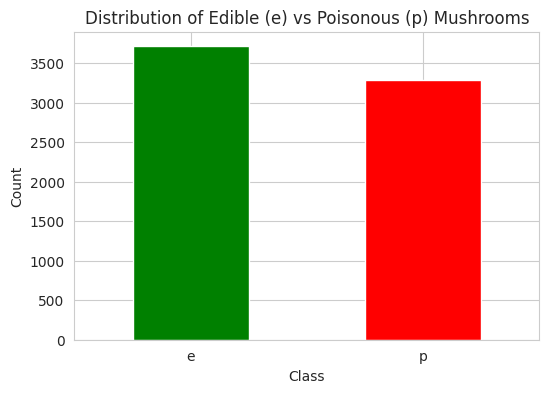

Class distribution:
class
e    0.530286
p    0.469714
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6,4))
train['class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Edible (e) vs Poisonous (p) Mushrooms')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

print('Class distribution:')
print(train['class'].value_counts(normalize=True))

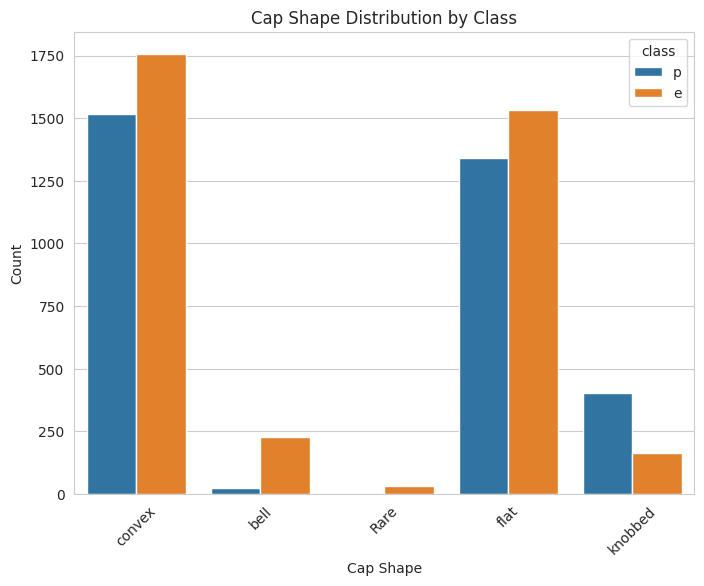

In [11]:
plt.figure(figsize=(8,6))
sns.countplot(data=train, x='cap-shape', hue='class')
plt.title('Cap Shape Distribution by Class')
plt.xlabel('Cap Shape')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

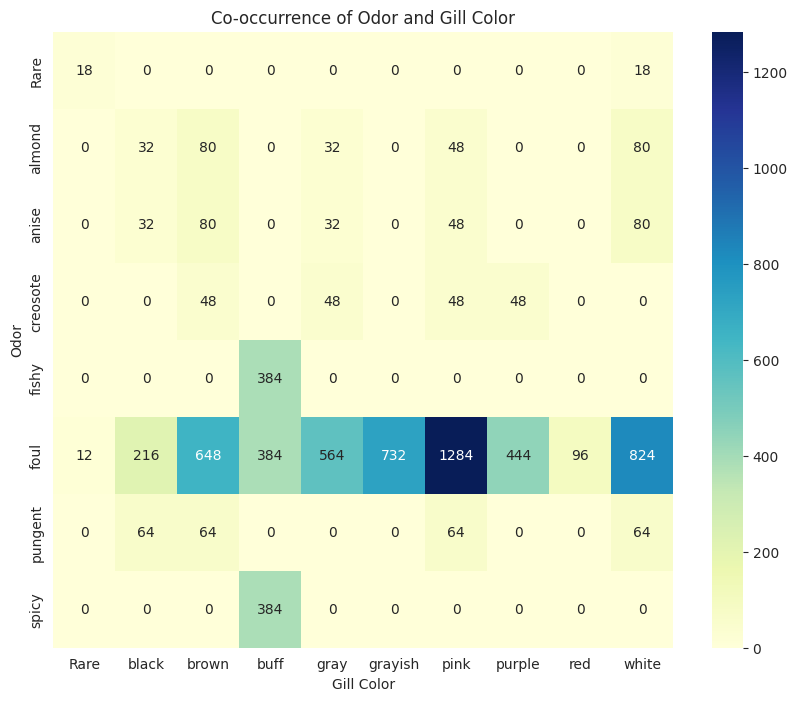

In [12]:
plt.figure(figsize=(10,8))
odor_gill = pd.crosstab(train['odor'], train['gill-color'])
sns.heatmap(odor_gill, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Co-occurrence of Odor and Gill Color')
plt.xlabel('Gill Color')
plt.ylabel('Odor')
plt.show()

# 7. Scale Numerical features and Encode Categorical features.

In [13]:
# Separate features and target
X = train.drop(columns=['ID', 'mushroom_id', 'class'])
y = train['class']

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Identify categorical columns in features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Since there are no numerical columns, we will only use OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Fit the preprocessor on the training data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print('Processed training shape:', X_train_processed.shape)
print('Processed validation shape:', X_val_processed.shape)

Processed training shape: (5600, 92)
Processed validation shape: (1400, 92)


# 8. Model Building (at least 7).

In [14]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gaussian Naive Bayes': GaussianNB()
}

import scipy.sparse as sp

results = []
for name, model in models.items():
    if sp.issparse(X_train_processed) and name == 'Gaussian Naive Bayes':
        X_tr = X_train_processed.toarray()
        X_va = X_val_processed.toarray()
    else:
        X_tr = X_train_processed
        X_va = X_val_processed

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_va)
    acc = accuracy_score(y_val, y_pred)
    results.append({'Model': name, 'Accuracy': acc})
    print(f'{name}: {acc:.4f}')

Logistic Regression: 1.0000
K-Nearest Neighbors: 1.0000
Support Vector Machine: 1.0000
Decision Tree: 1.0000
Random Forest: 1.0000
Gradient Boosting: 1.0000
AdaBoost: 0.9950
Gaussian Naive Bayes: 0.9936


# 9. Hyperparameter Tuning on any 3 of the models.

In [15]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

param_grid_gbm = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'linear']
}

print('Tuning Random Forest...')
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_processed, y_train)
print('Best RF params:', rf_grid.best_params_)
print('Best RF CV accuracy:', rf_grid.best_score_)

print('\nTuning Gradient Boosting...')
gbm_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gbm, cv=3, scoring='accuracy', n_jobs=-1)
gbm_grid.fit(X_train_processed, y_train)
print('Best GBM params:', gbm_grid.best_params_)
print('Best GBM CV accuracy:', gbm_grid.best_score_)

print('\nTuning SVM...')
svm_grid = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_processed, y_train)
print('Best SVM params:', svm_grid.best_params_)
print('Best SVM CV accuracy:', svm_grid.best_score_)

tuned_models = {
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'Gradient Boosting (Tuned)': gbm_grid.best_estimator_,
    'SVM (Tuned)': svm_grid.best_estimator_
}

for name, model in tuned_models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_val_processed)
    acc = accuracy_score(y_val, y_pred)
    print(f'{name}: {acc:.4f}')

Tuning Random Forest...
Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best RF CV accuracy: 1.0

Tuning Gradient Boosting...
Best GBM params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Best GBM CV accuracy: 1.0

Tuning SVM...
Best SVM params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM CV accuracy: 1.0
Random Forest (Tuned): 1.0000
Gradient Boosting (Tuned): 1.0000
SVM (Tuned): 1.0000


# 10. Comparison of model performances.

                        Model  Accuracy      Type
0         Logistic Regression  1.000000  Baseline
1         K-Nearest Neighbors  1.000000  Baseline
2      Support Vector Machine  1.000000  Baseline
3               Decision Tree  1.000000  Baseline
4               Random Forest  1.000000  Baseline
5           Gradient Boosting  1.000000  Baseline
8       Random Forest (Tuned)  1.000000     Tuned
10                SVM (Tuned)  1.000000     Tuned
9   Gradient Boosting (Tuned)  1.000000     Tuned
6                    AdaBoost  0.995000  Baseline
7        Gaussian Naive Bayes  0.993571  Baseline


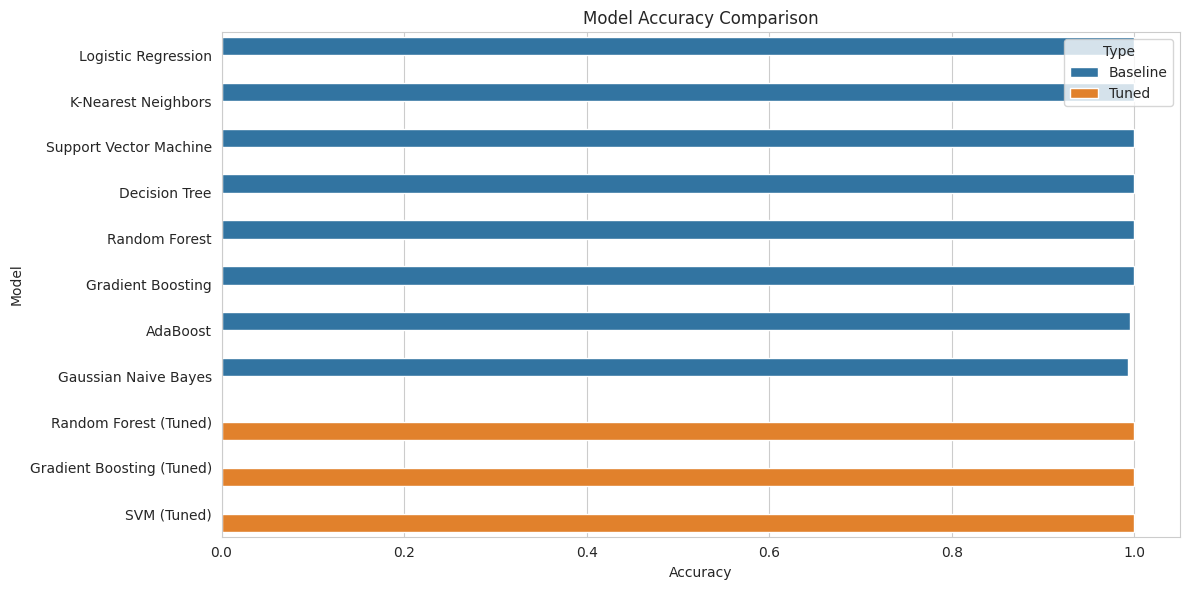

In [16]:
def evaluate_models(model_dict, model_type):
    results = []
    for name, model in model_dict.items():
        if isinstance(model, GaussianNB) and sp.issparse(X_train_processed):
            X_tr = X_train_processed.toarray()
            X_va = X_val_processed.toarray()
        else:
            X_tr = X_train_processed
            X_va = X_val_processed

        model.fit(X_tr, y_train)
        y_pred = model.predict(X_va)
        acc = accuracy_score(y_val, y_pred)
        results.append({'Model': name, 'Accuracy': acc, 'Type': model_type})
    return results

all_results = evaluate_models(models, 'Baseline') + evaluate_models(tuned_models, 'Tuned')

results_df = pd.DataFrame(all_results)
print(results_df.sort_values('Accuracy', ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Accuracy', y='Model', hue='Type', dodge=True)
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# 11. Final Model and Submission

In [17]:
best_model_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model']
print('Best model:', best_model_name)

if 'Tuned' in best_model_name:
    model_name_map = {
        'Random Forest (Tuned)': 'Random Forest',
        'Gradient Boosting (Tuned)': 'Gradient Boosting',
        'SVM (Tuned)': 'SVC'
    }
    base_name = model_name_map[best_model_name]
    if base_name == 'Random Forest':
        best_model = rf_grid.best_estimator_
    elif base_name == 'Gradient Boosting':
        best_model = gbm_grid.best_estimator_
    else:
        best_model = svm_grid.best_estimator_
else:
    best_model = models[best_model_name]

print('Training best model on full training data...')
best_model.fit(X_train_processed, y_train)

X_test = test.drop(columns=['ID', 'mushroom_id'])
X_test_processed = preprocessor.transform(X_test)

test_predictions = best_model.predict(X_test_processed)
test_predictions = label_encoder.inverse_transform(test_predictions)

submission = pd.DataFrame({
    'ID': test['ID'],
    'class': test_predictions
})

submission.to_csv('submission.csv', index=False)
print('Submission saved to submission.csv')
print(submission.head())

print('\nPrediction distribution:')
print(submission['class'].value_counts())

Best model: Logistic Regression
Training best model on full training data...
Submission saved to submission.csv
   ID class
0   1     e
1   2     e
2   3     e
3   4     e
4   5     e

Prediction distribution:
class
p    696
e    428
Name: count, dtype: int64
